### **Feature Detection - Corner**
* [] Harris and SubPix
* [] FAST
* [] ORB

Corner -> tepi tajam sudut

* flat = intensitas cahayanya sama
* edge = intensitas cahaya berubah 1 arah aja, hah wkwkwk

corner adalah teknik cv yang menggunakan untuk menemukan corner like point di sebuah gambar berlokasi di perubahan intensitas dsb

corner lebih stabli, karena 

corner ga mungkin tiba2 berubah, jadi deteksi corner aja lebih ez

cara kerja harris:
gerak kernel, hitung gardien x y, cek mana perubahan minimal 2 arah, masukin rumusnya, r harus positif

In [1]:
# Select interpreter (ctrl+shift+p) > Python: Select Interpreter > pilih yang sesuai dengan environment yang digunakan
import cv2
import matplotlib.pyplot as plt
# from matplotlib import pyplot as plt (sama aja)
import numpy as np

import os

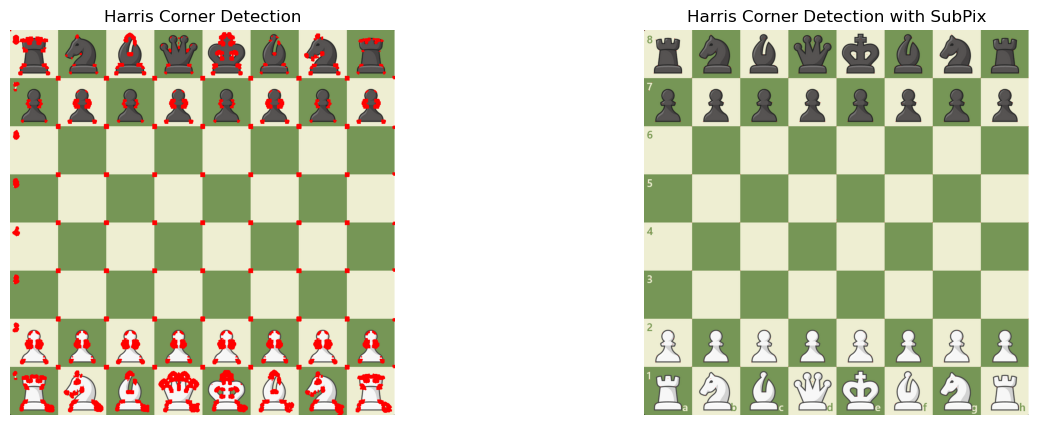

In [9]:
img = cv2.imread("chess.png")
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) # convert ke grayscale karena harris cuma butuh 1 channel, jadi kalau misalnya gambarnya RGB, nanti di convert ke grayscale dulu
img_gray = np.float32(img_gray) #   convert dari uint8 ke float32 supaya harris lebih stabil, karena nanti akan ada pembagian dengan nilai yang kecil pake numpy

# 1. Harris Corner Detection
# haris itung pembagian dan turunan sumbu x dan y
# (img, blocksize, ksize, k)
harris = cv2.cornerHarris(img_gray, 10, 5, 0.04)
# ksize = kernel size adalah kernel yang dipakai untuk meneghitung turunan gambarnya
# blocksize = menentukan ukuran area yang nanti nentuin area sudut atau bukan
# k = parameter bebas yang digunakan dalam skor R du Harris, biasanya antara 0.04-0.06

img_result = img.copy() # deep copy img aslinya supaya ga keganggu
img_result[harris > 0.01 * harris.max()] = [0, 0, 255] # Jadi kondisi dimana skor harris yang lebih dari 0.01 * corner terkuat baru mau di display
img_result = cv2.cvtColor(img_result, cv2.COLOR_BGR2RGB) # cvt karena mau ditampilkan pake matplotlib, jadi harus di convert ke RGB, karena defaultnya itu BGR

# knp di convert? karena pake matplotlib, jadi harus di convert ke RGB, karena defaultnya itu BGR
# kalau pake opencv, gak perlu convert karena defaultnya BGR

# 2. Harris Corner with SubPix
_, thresh = cv2.threshold(harris, 0.01 * harris.max(), 255, cv2.THRESH_BINARY) # thresholding untuk bikin binary image dari hasil harris, jadi nanti yang lebih dari 0.01 * corner terkuat itu akan jadi 255 (putih), yang lainnya 0 (hitam)
thresh = np.uint8(thresh) # convert dari float ke uint8 karena findContours butuh inputan uint8

# mau nyari titik centroid (pusat) dari setiap contour yang ditemukan, jadi nanti kita bisa refine titik sudutnya pake subpix
_, _, _, corner_centroids = cv2.connectedComponentsWithStats(thresh) # connectedComponentsWithStats itu buat nyari connected components di binary image, jadi nanti dia bakal ngasih tau ada berapa contour yang ditemukan, terus juga ngasih tau posisi centroidnya
corner_centroids = np.float32(corner_centroids) # convert ke float32 supaya bisa dipake di cornerSubPix

# Criteria -> condition berhenti algorithm nya
#iterasinya max 100, atau kalau perubahan posisi titik sudutnya kurang dari 0.001 pixel
criteria = (cv2.TermCriteria_MAX_ITER + cv2.TermCriteria_EPS, 100, 0.001)

corners = cv2.cornerSubPix(img_gray, corner_centroids, (5, 5), (-1, -1), criteria) # refine titik sudutnya pake subpix, jadi nanti dia bakal ngasih tau posisi titik sudut yang lebih akurat

# winSize = 5 -> area pencarian centroid yang paling bagusnya
# zeroZone = -1 -> area sekitar winSize yang ga pengen dihitung buat mencegah noise

with_subPix = img.copy() # deep copy gambar asli yang berwarna supaya nanti bisa ditandain titik sudut yang udah di refine pake subpix
corners = np.int16(corners) # buletin hasil float dari subpix biar jela ketika jadi koordinat
for corner in corners: # iterasi buat dapetin koordinat x dan y dari corner buat jadi warna merah
    corner_X, corner_y = corner[0], corner[1]
    with_subPix[corner_y, corner_X] = [0, 0, 255] # tandain titik sudut yang udah di refine pake subpix dengan warna merah
with_subPix = cv2.cvtColor(with_subPix, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1) # ini untuk harris corner detection tanpa subpix
plt.imshow(img_result)
plt.title("Harris Corner Detection")
plt.axis('off')
plt.subplot(1, 2, 2) # ini untuk subpix
plt.imshow(with_subPix)
plt.title("Harris Corner Detection with SubPix")
plt.axis('off')
plt.show()

SubPix mendeteksi sudut yang lebih akurat, jadi nanti setelah dideteksi pake harris, kita bisa refine lagi pake subpix supaya titik sudutnya lebih akurat


subpix itu refine dari harris, jadi nanti setelah dideteksi pake harris, kita bisa refine lagi pake subpix supaya titik sudutnya lebih akurat

FAST detection corner lebih cepet, ga ngitung2 lagi kaya haris

ada pixel tengah nah dia deteksi lingkaaran 16 pixel

nah dia ngebandingin lebih terang atu gelap pixel yang disekitarnya, lebih cepet karena dia ngecek 4 korner dulu

rank based quality pake scoring, itung juga tapi ga seribet haris

bisa handle rotasi twtwo bakal bisa deteksi cornernya dmn

condong ke arah mana



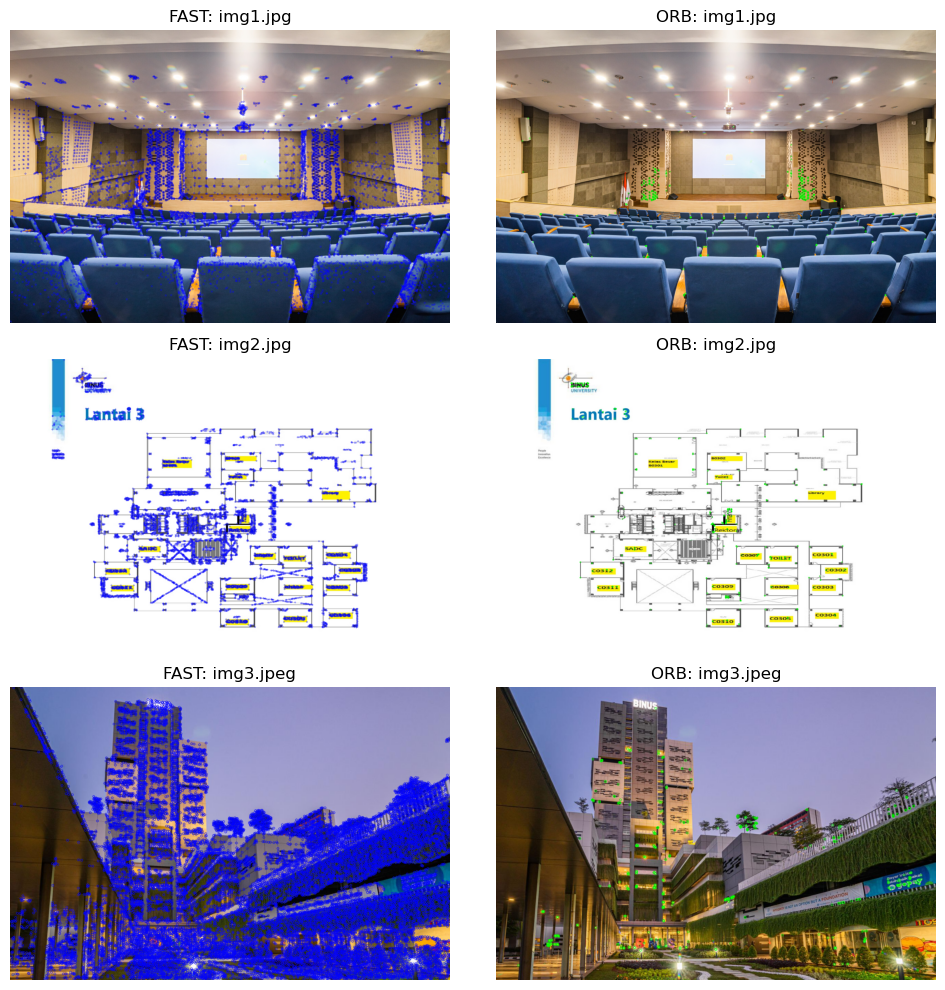

In [11]:
plt.figure(figsize=(10, 10))
folder_path = 'images' # kalo pake + harus ada slash di blkgnya 'images\'
images_files = os.listdir(folder_path)
# print(images_files)

for i, filename in enumerate(images_files):
    img = cv2.imread(os.path.join(folder_path, filename))
    # img = cv2.imread(folder_path + filename)

    fast = cv2.FastFeatureDetector_create() # buat deteksi fitur dengan FAST
    keypoints_fast = fast.detect(img) # deteksi keypoint di gambar
    fast_rest = cv2.drawKeypoints(img, keypoints_fast, None, color=(255, 0, 0)) # gambar keypoint yang udah dideteksi pake warna merah

    orb = cv2.ORB_create() # buat deteksi fitur dengan ORB
    keypoints_orb = orb.detect(img) # deteksi keypoint di gambar
    orb_res = cv2.drawKeypoints(img, keypoints_orb, None, color=(0, 255, 0)) # gambar keypoint yang udah dideteksi pake warna hijau

    fast_res = cv2.cvtColor(fast_rest, cv2.COLOR_BGR2RGB) # convert ke RGB supaya bisa ditampilkan pake matplotlib
    orb_res = cv2.cvtColor(orb_res, cv2.COLOR_BGR2RGB)

    plt.subplot(len(images_files), 2, i*2 + 1) # buat nampilin hasil FAST di sebelah kiri
    plt.imshow(fast_res)
    plt.title(f"FAST: {filename}")
    plt.axis('off')

    plt.subplot(len(images_files), 2, i*2 + 2) # buat nampilin hasil ORB di sebelah kanan
    plt.imshow(orb_res)
    plt.title(f"ORB: {filename}")
    plt.axis('off')

plt.tight_layout()
plt.show()
